<div style="padding: 20px; background-color: #f8f9f9; border-radius: 10px; border-left: 10px solid #2e86c1;">
    <h1 style="color: #2e86c1; margin-bottom: 5px;">🚀 Retailrocket Customer Segmentation</h1>
    <p style="font-size: 1.1em; color: #566573;">Unsupervised Learning Pipeline for Behavioral Clustering</p>
</div>

### Project Overview
This notebook implements a complete data science pipeline to segment customers based on their shopping behavior using the Retailrocket eCommerce dataset. We utilize **RFM (Recency, Frequency, Monetary)** analysis to transform raw event data into actionable customer profiles.

### Setup Dataset

In [7]:
from src.dataset import setup_data
setup_data()

Create directory ./dataset
Dataset URL: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset
Download completed successfully!


In [8]:
import pandas as pd
import numpy as np
from src.data_integration import load_data, merge_data
from src.cleaning_data import clean_data
from src.features import calculate_rfm, prepare_features

data_paths = [
    './dataset/events.csv', 
    './dataset/item_properties_part1.csv', 
    './dataset/item_properties_part2.csv', 
    './dataset/category_tree.csv'
]

--- 
## 🛠️ Phase 1: Data Integration & Cleaning
In this phase, we aggregate multiple data sources (events, item properties, and category trees) into a single unified dataset. 

> **Key Operations:**
> - **Deduplication:** Removing redundant event logs.
> - **Temporal Alignment:** Extracting the latest properties for each item.
> - **ID Standardization:** Ensuring consistent data types across relational joins.

In [5]:
# Load and Merge
csv_data = [load_data(p) for p in data_paths]
df_merged = merge_data(csv_data)

# Clean
df_cleaned = clean_data(df_merged)
df_cleaned.head()

Original shape: (2756101, 7)
Cleaned shape: (21982, 7)


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid
130,2015-06-02 05:17:56.276,599528,transaction,356475,4000.0,386,1095.0
304,2015-06-01 21:18:20.981,121688,transaction,15335,11117.0,1098,897.0
418,2015-06-01 21:25:15.008,552148,transaction,81345,5444.0,1393,1383.0
814,2015-06-01 16:38:56.375,102019,transaction,150318,13556.0,1236,1141.0
843,2015-06-01 16:01:58.180,189384,transaction,310791,7244.0,437,92.0


--- 
## 🧠 Phase 2: Feature Engineering (RFM Analysis)
We calculate three core metrics for each user to capture their behavioral signature:

| Metric | Description | Weighting |
| :--- | :--- | :--- |
| **Recency** | Days since the user's last interaction | 1.0 |
| **Frequency** | Total number of interactions (Views, Carts, Purchases) | 1.0 |
| **Monetary** | Weighted Engagement Score | View=1, Cart=3, Trans=5 |

Since exact price data is unavailable, we use the **Engagement Score** as a proxy for the 'Monetary' value.

In [20]:
# Calculate RFM Scores
rfm_df = calculate_rfm(df_cleaned)
rfm_df.head()

,Recency,Frequency,Monetary
visitorid,,,
172,34,2,10
186,36,1,5
264,10,2,10
419,50,1,5
539,93,1,5


--- 
## ⚖️ Phase 3: Scaling & Outlier Handling
Clustering algorithms like **K-Means** are distance-based and sensitive to scale. We normalize our features to ensure each dimension contributes equally to the model.

1. **Log Transformation:** Normalizes highly skewed distributions (e.g., Frequency).
2. **Standard Scaling:** Centers data around zero with unit variance.

In [21]:
# Apply Log Transformation and Scaling
features_scaled = prepare_features(rfm_df)

# Final Data Check
print("Final Feature Set Info:")
features_scaled.info()
features_scaled.head()

Final Feature Set Info:
<class 'pandas.core.frame.DataFrame'>
Index: 11569 entries, 172 to 1407398
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    11569 non-null  float64
 1   Frequency  11569 non-null  float64
 2   Monetary   11569 non-null  float64
dtypes: float64(3)
memory usage: 361.5 KB


,Recency,Frequency,Monetary
visitorid,,,
172,-0.512093,0.630320,0.786269
186,-0.448539,-0.382923,-0.416137
264,-1.835857,0.630320,0.786269
419,-0.081521,-0.382923,-0.416137
539,0.617808,-0.382923,-0.416137


--- 
## 🤖 Phase 4: Modeling & Evaluation
We implement **K-Means** as our primary clustering model. To determine the optimal number of segments, we use the **Elbow Method** and validate with **Silhouette Scores**.

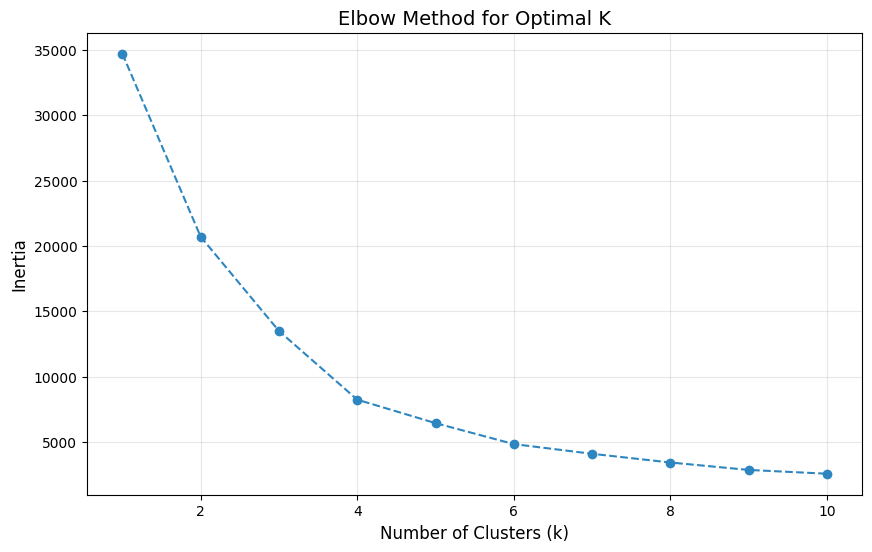

Silhouette Score for K=4: 0.604


In [22]:
from src.models import run_kmeans, plot_elbow, calculate_silhouette, run_dbscan

# 1. Find optimal K
plot_elbow(features_scaled)

# 2. Train final model (example with k=4, adjust based on plot)
k_optimal = 4
kmeans_labels = run_kmeans(features_scaled, k=k_optimal)

# 3. Evaluate
score = calculate_silhouette(features_scaled, kmeans_labels)
print(f"Silhouette Score for K={k_optimal}: {score:.3f}")

--- 
## 💡 Phase 5: Insights & Recommendations
Mathematical clusters are now translated into actionable business personas. We analyze the average **Recency, Frequency, and Monetary** traits for each group to define our strategy.

In [23]:
from src.analysis import get_cluster_profiles, get_business_strategies

# 1. Generate Profiles
profiles = get_cluster_profiles(rfm_df, kmeans_labels)
display(profiles)

# 2. Strategic Recommendations
strategies = get_business_strategies(profiles)
display(strategies)

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,85.65,1.00,5.00,7036
1,60.67,34.93,174.67,195
2,16.13,1.12,5.58,2241
3,75.89,2.69,13.43,2097


,Persona,Strategy
Cluster,,
0,Window Shoppers,Retarget with popular items; Awareness campaigns.
1,At Risk / Churning,Send re-engagement emails; Discount codes for ...
2,Window Shoppers,Retarget with popular items; Awareness campaigns.
3,Window Shoppers,Retarget with popular items; Awareness campaigns.
